# Nya dataset på steam spel

In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import seaborn as sns

# Ladda in data
Kommer få ha csv i en zip och inte ladda upp den eftersom github inte tilåter större än 100MB filer så här är länken: 
https://www.kaggle.com/datasets/fronkongames/steam-games-dataset/data

In [167]:
with zipfile.ZipFile("data/archive.zip") as z:
    with z.open("games.csv") as f:
        df = pd.read_csv(f, index_col=False)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122611 entries, 0 to 122610
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       122611 non-null  int64  
 1   Name                        122610 non-null  str    
 2   Release date                122611 non-null  str    
 3   Estimated owners            122611 non-null  str    
 4   Peak CCU                    122611 non-null  int64  
 5   Required age                122611 non-null  int64  
 6   Price                       122611 non-null  float64
 7   DiscountDLC count           122611 non-null  int64  
 8   About the game              122611 non-null  int64  
 9   Supported languages         114162 non-null  str    
 10  Full audio languages        122611 non-null  str    
 11  Reviews                     122611 non-null  str    
 12  Header image                12070 non-null   str    
 13  Website                  

In [168]:
df.isnull().sum()

AppID                              0
Name                               1
Release date                       0
Estimated owners                   0
Peak CCU                           0
Required age                       0
Price                              0
DiscountDLC count                  0
About the game                     0
Supported languages             8449
Full audio languages               0
Reviews                            0
Header image                  110541
Website                           81
Support url                    72935
Support email                  68469
Windows                        22263
Mac                                0
Linux                              0
Metacritic score                   0
Metacritic url                     0
User score                    118355
Positive                           0
Negative                           0
Score rank                         0
Achievements                  122571
Recommendations                    0
N

In [169]:
df = df.copy()

df = df.dropna(subset=[
    "Name",
    "Price",
    "Average playtime forever",
    "Positive",
    "Negative"
])

In [170]:
print(df.columns)

Index(['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'DiscountDLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'],
      dtype='str')


In [171]:
df.isnull().sum()

AppID                             0
Name                              0
Release date                      0
Estimated owners                  0
Peak CCU                          0
Required age                      0
Price                             0
DiscountDLC count                 0
About the game                    0
Supported languages              56
Full audio languages              0
Reviews                           0
Header image                  20499
Website                           8
Support url                   13837
Support email                 13130
Windows                        2829
Mac                               0
Linux                             0
Metacritic score                  0
Metacritic url                    0
User score                    21792
Positive                          0
Negative                          0
Score rank                        0
Achievements                  22425
Recommendations                   0
Notes                       

# Efter clean up

==============================================================

# Antal spel per år
Eftersom datasetet är fram till 2025 så ser vi en stark dipp men från 2015 så ser vi en stadig ökning

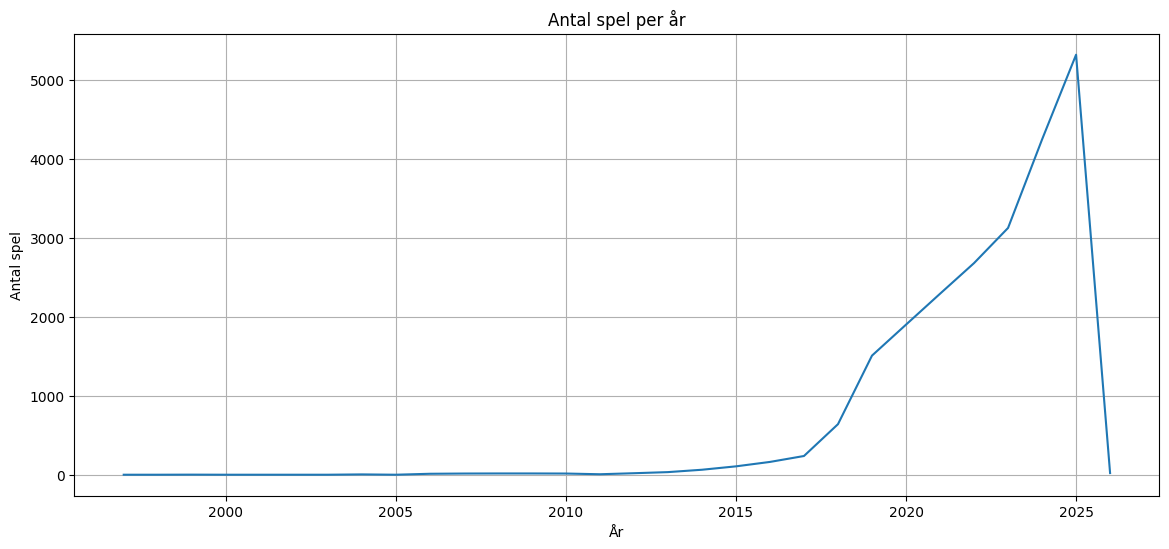

In [173]:
# Konvertera datum
df["Release date"] = pd.to_datetime(df["Release date"], errors="coerce")

# Ta bort rader utan datum
df = df.dropna(subset=["Release date"])

# Sortera
df = df.sort_values("Release date")

# antal spel per år
games_per_year = df["Release date"].dt.year.value_counts().sort_index()

# figur
plt.figure(figsize=(14, 6))

games_per_year.plot(kind="line")

plt.title("Antal spel per år")
plt.xlabel("År")
plt.ylabel("Antal spel")

plt.grid(True)

plt.show()

# Byta platts på Genre och Tags
Detta gör jag eftersom dem är tvärtom från vad dem ska vara.

In [174]:
df = df.rename(columns={
    "Genres": "Tags_temp",
    "Tags": "Genres"
})

df = df.rename(columns={
    "Tags_temp": "Tags"
})

# Top Antal Genres
Antal spel per genre

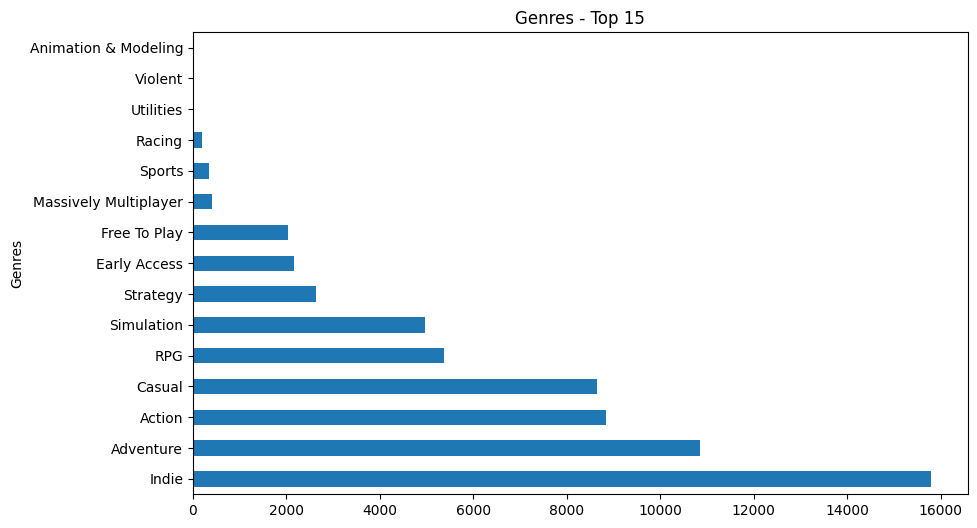

In [175]:
genres = df["Genres"].str.split(",").explode()
genres.value_counts().head(15).plot(kind="barh", figsize=(10,6))
plt.title("Genres - Top 15")
plt.show()

# Heatmap Samband mellan olika numeriska variabler
En korrelations-heatmap som visar sambandet mellan olika numeriska variabler i Steam-datasetet, såsom pris, popularitet, betyg och spelaktivitet.

En intressant observation är att Peak CCU (antal samtidiga spelare) har en stark positiv korrelation med antalet negativa reviews. Detta tyder inte nödvändigtvis på att fler spelare leder till sämre upplevelse, utan snarare att större spel genererar fler reviews totalt.

Däremot ser vi att korrelationen mellan Peak CCU och Positive reviews är nästan noll, vilket innebär att det inte finns något tydligt linjärt samband mellan antal spelare och antal positiva reviews i denna data.

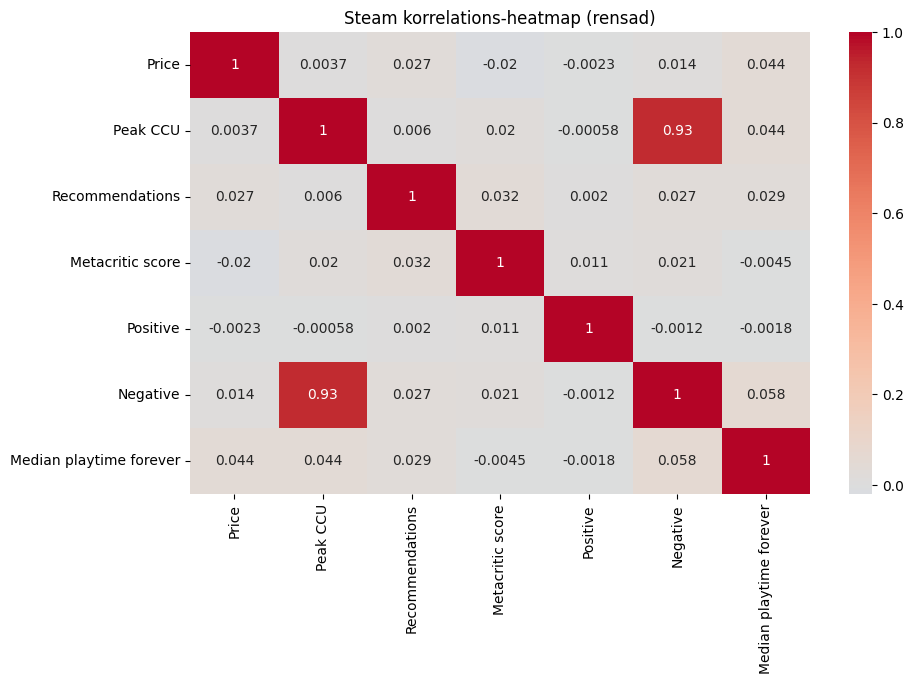

In [182]:
cols = [
    'Price', 'Peak CCU', 'Recommendations',
    'Metacritic score',
    'Positive', 'Negative',
    'Median playtime forever'
]

df_clean = df[cols].apply(pd.to_numeric, errors='coerce')

corr = df_clean.corr()

plt.figure(figsize=(10, 6))

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)

plt.title("Steam korrelations-heatmap (rensad)")
plt.show()

# Boxploten visar hur priset varierar mellan olika genrer 
Efter att spel över 50$ har filtrerats bort för att minska påverkan av extrema outliers. Resultatet visar att de flesta genrer har en låg medianprisnivå, ofta under 10$, vilket indikerar att majoriteten av spelen på marknaden är relativt billiga eller free-to-play.

Vissa genrer, såsom Animation & Modeling samt Software & Game Development, har en större spridning i pris, vilket innebär att de innehåller både mycket billiga och dyrare spel.

Free-to-play kategorin visar även vissa utstickare i pris, vilket kan bero på att dessa spel ofta erbjuder betalbara tillägg som DLC eller in-game purchases. Detta är dock en tolkning och inte en direkt slutsats från datan.

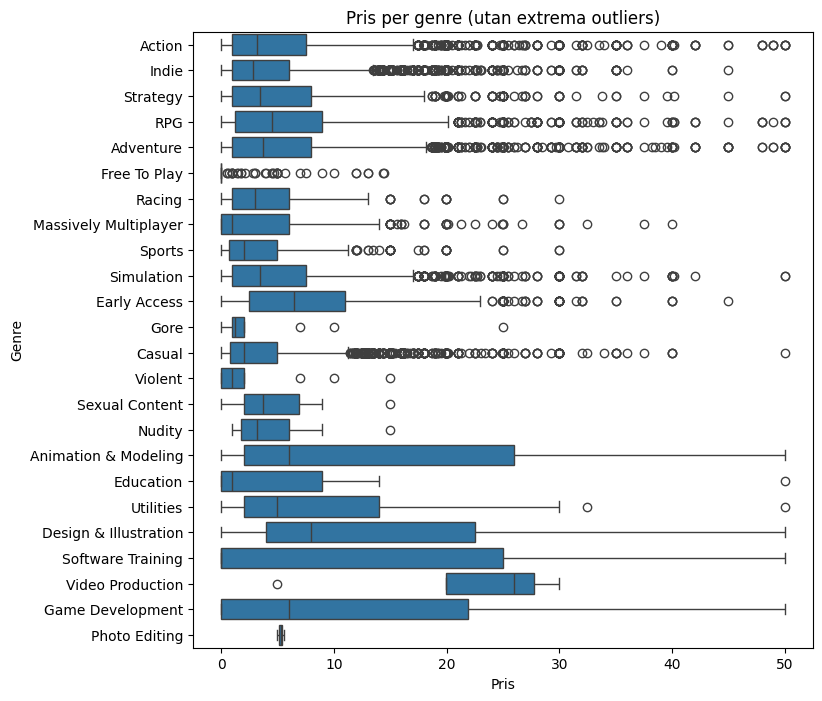

In [ ]:
df_genre = df.copy()

df_genre['Genres'] = df_genre['Genres'].str.split(',')
df_genre = df_genre.explode('Genres')
df_genre = df_genre.reset_index(drop=True)

df_genre['Genres'] = df_genre['Genres'].str.strip()

df_genre = df_genre[df_genre['Price'] <= 50]

plt.figure(figsize=(8,8))

sns.boxplot(x='Price', y='Genres', data=df_genre)

plt.title("Pris per genre")
plt.xlabel("Pris")
plt.ylabel("Genre")
plt.show()